In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/train.csv.zip", encoding='latin1')

In [ ]:
df.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [ ]:
df.shape

(27481, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   textID            27481 non-null  object 
 1   text              27480 non-null  object 
 2   selected_text     27480 non-null  object 
 3   sentiment         27481 non-null  object 
 4   Time of Tweet     27481 non-null  object 
 5   Age of User       27481 non-null  object 
 6   Country           27481 non-null  object 
 7   Population -2020  27481 non-null  int64  
 8   Land Area (Km²)   27481 non-null  float64
 9   Density (P/Km²)   27481 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 2.1+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
textID,0
text,1
selected_text,1
sentiment,0
Time of Tweet,0
Age of User,0
Country,0
Population -2020,0
Land Area (Km²),0
Density (P/Km²),0


In [ ]:
df = df.dropna(subset=['selected_text','selected_text'])

In [ ]:
df.isnull().sum()

,0
textID,0
text,0
selected_text,0
sentiment,0
Time of Tweet,0
Age of User,0
Country,0
Population -2020,0
Land Area (Km²),0
Density (P/Km²),0


In [ ]:
sentiment=df['sentiment'].value_counts()

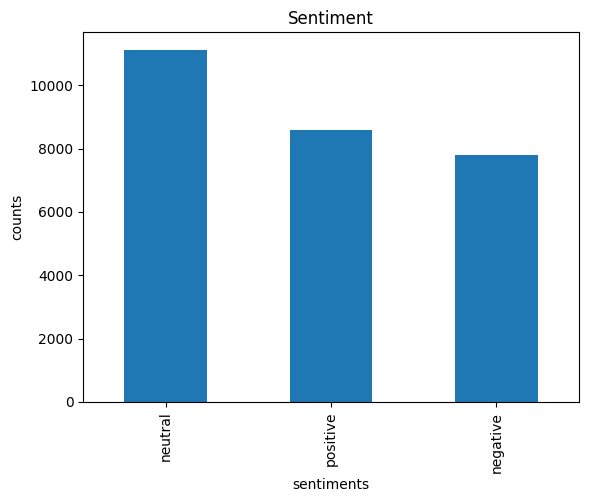

<Figure size 1000x800 with 0 Axes>

In [ ]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment")
plt.xlabel("sentiments")
plt.ylabel('counts')
plt.figure(figsize=(10,8))
plt.show()

In [ ]:
df['processed_text_lowercase'] = df['text'].astype(str).apply(lambda x: x.lower())
df['processed_selected_text_lowercase'] = df['selected_text'].astype(str).apply(lambda x: x.lower())

display(df[['text', 'processed_text_lowercase', 'selected_text', 'processed_selected_text_lowercase']].head())

,text,processed_text_lowercase,selected_text,processed_selected_text_lowercase
0,"I`d have responded, if I were going","i`d have responded, if i were going","I`d have responded, if I were going","i`d have responded, if i were going"
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad i will miss you here in san diego!!!,Sooo SAD,sooo sad
2,my boss is bullying me...,my boss is bullying me...,bullying me,bullying me
3,what interview! leave me alone,what interview! leave me alone,leave me alone,leave me alone
4,"Sons of ****, why couldn`t they put them on t...","sons of ****, why couldn`t they put them on t...","Sons of ****,","sons of ****,"


In [ ]:
import string
import re

def remove_punctuation(text):
    return re.sub(f'[{re.escape(string.punctuation)}]', '', text)

# Apply punctuation removal
df['processed_text_no_punct'] = df['processed_text_lowercase'].apply(remove_punctuation)
df['processed_selected_text_no_punct'] = df['processed_selected_text_lowercase'].apply(remove_punctuation)

display(df[['processed_text_lowercase', 'processed_text_no_punct', 'processed_selected_text_lowercase', 'processed_selected_text_no_punct']].head())

,processed_text_lowercase,processed_text_no_punct,processed_selected_text_lowercase,processed_selected_text_no_punct
0,"i`d have responded, if i were going",id have responded if i were going,"i`d have responded, if i were going",id have responded if i were going
1,sooo sad i will miss you here in san diego!!!,sooo sad i will miss you here in san diego,sooo sad,sooo sad
2,my boss is bullying me...,my boss is bullying me,bullying me,bullying me
3,what interview! leave me alone,what interview leave me alone,leave me alone,leave me alone
4,"sons of ****, why couldn`t they put them on t...",sons of why couldnt they put them on the rel...,"sons of ****,",sons of


In [ ]:
def remove_numbers_and_extra_spaces(text):
    text = re.sub('\d+', '', text)
    text = re.sub('\s+', ' ', text).strip()
    return text

df['processed_text_clean'] = df['processed_text_no_punct'].apply(remove_numbers_and_extra_spaces)
df['processed_selected_text_clean'] = df['processed_selected_text_no_punct'].apply(remove_numbers_and_extra_spaces)

display(df[['processed_text_no_punct', 'processed_text_clean', 'processed_selected_text_no_punct', 'processed_selected_text_clean']].head())

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_846/2442100744.py:2: SyntaxWarning: invalid escape sequence '\d'
  text = re.sub('\d+', '', text) # Remove digits
/tmp/ipykernel_846/2442100744.py:3: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('\s+', ' ', text).strip() # Remove extra spaces and strip leading/trailing spaces


,processed_text_no_punct,processed_text_clean,processed_selected_text_no_punct,processed_selected_text_clean
0,id have responded if i were going,id have responded if i were going,id have responded if i were going,id have responded if i were going
1,sooo sad i will miss you here in san diego,sooo sad i will miss you here in san diego,sooo sad,sooo sad
2,my boss is bullying me,my boss is bullying me,bullying me,bullying me
3,what interview leave me alone,what interview leave me alone,leave me alone,leave me alone
4,sons of why couldnt they put them on the rel...,sons of why couldnt they put them on the relea...,sons of,sons of


In [ ]:
import nltk
from nltk.corpus import stopwords

# Download NLTK stopwords if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])

# Apply stopword removal
df['processed_text_final'] = df['processed_text_clean'].apply(remove_stopwords)
df['processed_selected_text_final'] = df['processed_selected_text_clean'].apply(remove_stopwords)

display(df[['text', 'processed_text_final', 'selected_text', 'processed_selected_text_final']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,text,processed_text_final,selected_text,processed_selected_text_final
0,"I`d have responded, if I were going",id responded going,"I`d have responded, if I were going",id responded going
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad miss san diego,Sooo SAD,sooo sad
2,my boss is bullying me...,boss bullying,bullying me,bullying
3,what interview! leave me alone,interview leave alone,leave me alone,leave alone
4,"Sons of ****, why couldn`t they put them on t...",sons couldnt put releases already bought,"Sons of ****,",sons


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer_text = TfidfVectorizer(max_features=5000)

X_text = tfidf_vectorizer_text.fit_transform(df['processed_text_final'])

tfidf_vectorizer_selected_text = TfidfVectorizer(max_features=5000)

X_selected_text = tfidf_vectorizer_selected_text.fit_transform(df['processed_selected_text_final'])

print("Shape of TF-IDF features for 'text':", X_text.shape)
print("Shape of TF-IDF features for 'selected_text':", X_selected_text.shape)

Shape of TF-IDF features for 'text': (27480, 5000)
Shape of TF-IDF features for 'selected_text': (27480, 5000)


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['sentiment_encoded'] = label_encoder.fit_transform(df['sentiment'])

sentiment_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Sentiment Encoding Mapping:", sentiment_mapping)

display(df[['sentiment', 'sentiment_encoded']].head())

Sentiment Encoding Mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


,sentiment,sentiment_encoded
0,neutral,1
1,negative,0
2,negative,0
3,negative,0
4,negative,0


In [ ]:
from scipy.sparse import hstack

X_combined = hstack([X_text, X_selected_text])

y = df['sentiment_encoded']

print("Shape of combined features (X_combined):", X_combined.shape)
print("Shape of target variable (y):", y.shape)

Shape of combined features (X_combined): (27480, 10000)
Shape of target variable (y): (27480,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (21984, 10000)
X_test shape: (5496, 10000)
y_train shape: (21984,)
y_test shape: (5496,)


In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
y_pred = log_reg_model.predict(X_test)

print("Predictions made on the test set.")

Predictions made on the test set.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.8111

Classification Report:
              precision    recall  f1-score   support

    negative       0.83      0.74      0.78      1556
     neutral       0.76      0.87      0.81      2223
    positive       0.87      0.79      0.83      1717

    accuracy                           0.81      5496
   macro avg       0.82      0.80      0.81      5496
weighted avg       0.82      0.81      0.81      5496



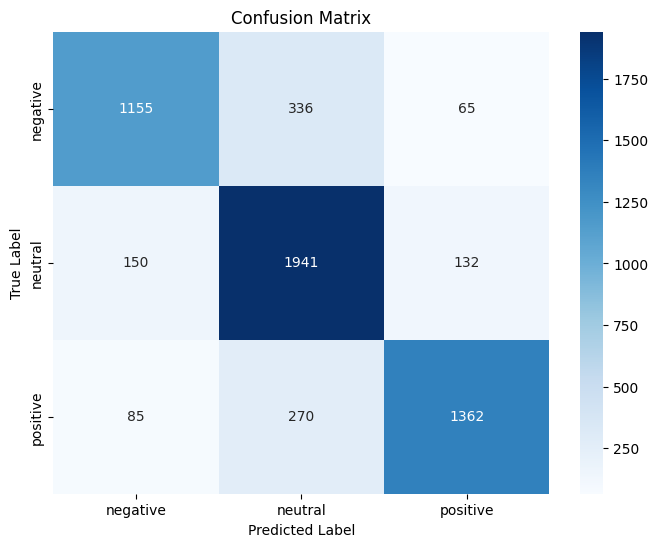

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()